# Load libraries

In [1]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate

# Modelling

In [2]:
# ZDT calling
# linear_model = LinearModel(problem = ZDT3(n_dim = 10), max_iter = 30, random_state = 42)
# choquet_model = ChoquetModel(problem = ZDT3(n_dim = 10), max_iter = 30, random_state = 42, method = 0)

# DTLZ calling
linear_model = LinearModel(problem = DTLZ1(n_dim = 10, n_obj = 2), max_iter = 20, random_state = 42)
choquet_model = ChoquetModel(problem = DTLZ1(n_dim = 10, n_obj = 2), max_iter = 20, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape} PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape}  PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (155, 2) PS (155, 10)
ChoquetModel:  PF (241, 2)  PS (241, 10)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,0.421010,4389,155,20,0.322041
ChoquetModel,0.431121,5698,241,20,2.054962


# Model visualisation

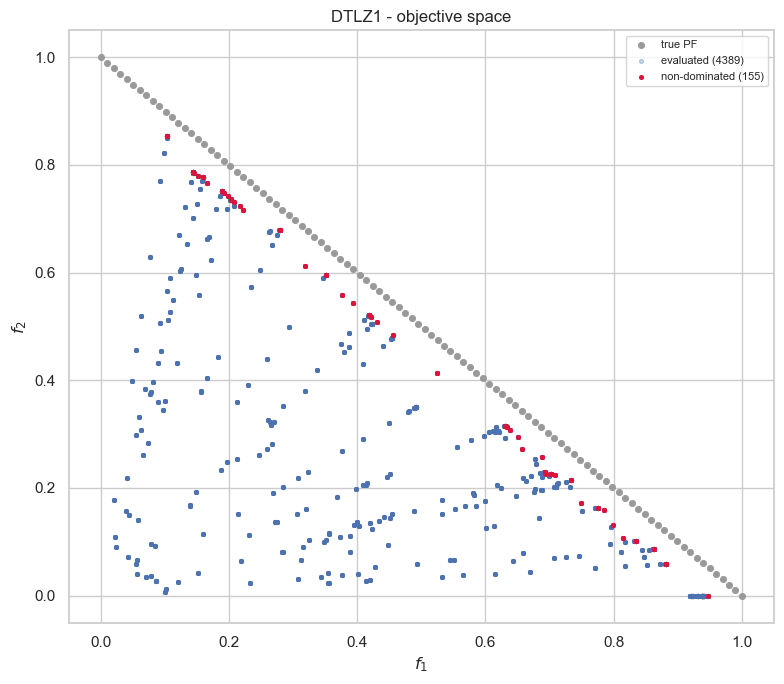

In [3]:
linear_model.visualise("objective");

## Linear Model

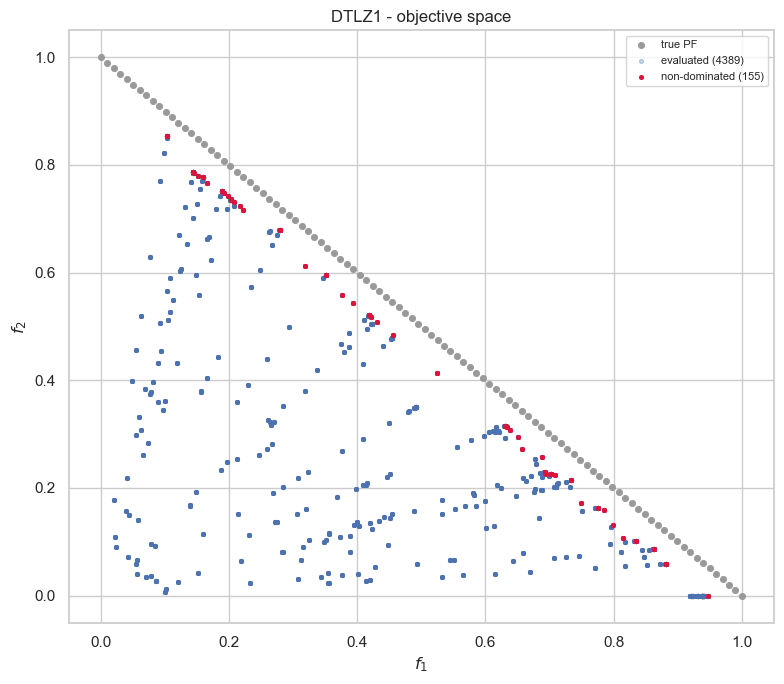

In [4]:
linear_model.visualise("objective");

In [5]:
linear_model.visualise("learning", show = False)

In [6]:
linear_model.visualise("learning", plot_scalarisation = True, show = False)

## Choquet Model

In [7]:
np.all((choquet_model.dec_hist >= 0) & (choquet_model.dec_hist <= 1))

np.True_

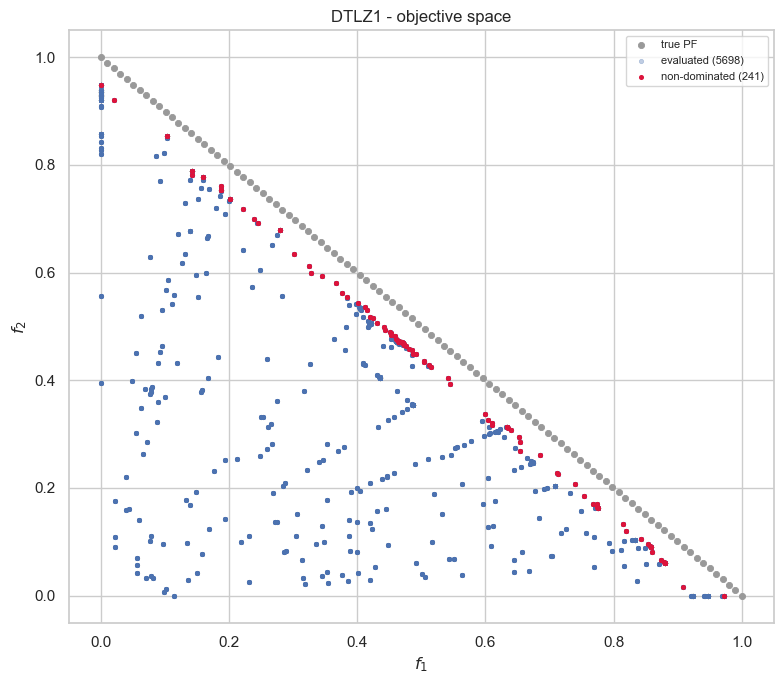

In [8]:
choquet_model.visualise("objective");

In [9]:
choquet_model.visualise("learning", show = False)

In [10]:
choquet_model.visualise("learning", plot_scalarisation = True, show = False)

# Benchmark

Every configuration is solved by both models from the same seed, then scored by `evaluate()` against one shared reference point.

- **ZDT1/2/3** are 2-objective by construction, so they appear once per `n_dim` and ignore `obj_dims`.
- **DTLZ1/2** take `n_obj`, and are skipped when `n_dim <= n_obj` - there would be no tail variables left to carry `g`.
- Hypervolume is comparable **within** a row group only; the reference point differs between configurations, so never compare it across problems or dimensions.

In [11]:
dec_dims   = [10, 20]
obj_dims   = [2, 3, 4, 5]
max_iter   = 15                 # ChoquetModel dominates the runtime; raise this knowingly
model_list = [LinearModel, ChoquetModel]
prob_list  = [ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2]


def build(problem, n_dim, n_obj):
    """This grid cell's problem, or None if the combination does not exist: ZDT is 2-objective by
       construction, and DTLZ needs n_dim > n_obj to leave tail variables to carry g."""
    if problem in (ZDT1, ZDT2, ZDT3):
        return problem(n_dim = n_dim) if n_obj == 2 else None
    return problem(n_dim = n_dim, n_obj = n_obj) if n_dim > n_obj else None


rows = []
for problem, n_dim, n_obj in itertools.product(prob_list, dec_dims, obj_dims):
    prob = build(problem, n_dim, n_obj)
    if prob is None:
        continue

    fitted = [model(problem = prob, max_iter = max_iter, random_state = 42,
                    **(dict(method = 2) if model is ChoquetModel else {}))
              for model in model_list]
    for m in fitted:
        m.solve()

    # evaluate() scores the pair against one shared reference point, and already times each solve
    rows.append(evaluate(fitted).assign(problem = problem.__name__, n_dim = n_dim,
                                        n_obj = prob.n_obj))
    print(problem.__name__, f"n_dim={n_dim}", f"n_obj={prob.n_obj}",
          dict(rows[-1]["wallclock_time"].round(1)))

results = (pd.concat(rows).rename_axis("model").reset_index()
             .set_index(["problem", "n_dim", "n_obj", "model"]).sort_index())
results

ZDT1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(0.4)}
ZDT1 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.6), 'ChoquetModel': np.float64(2.3)}
ZDT2 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(0.4)}
ZDT2 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(0.4)}
ZDT3 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.3), 'ChoquetModel': np.float64(1.1)}
ZDT3 n_dim=20 n_obj=2 {'LinearModel': np.float64(4.6), 'ChoquetModel': np.float64(2.7)}
DTLZ1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.3), 'ChoquetModel': np.float64(1.3)}
DTLZ1 n_dim=10 n_obj=3 {'LinearModel': np.float64(0.3), 'ChoquetModel': np.float64(14.5)}
DTLZ1 n_dim=10 n_obj=4 {'LinearModel': np.float64(0.3), 'ChoquetModel': np.float64(30.1)}
DTLZ1 n_dim=10 n_obj=5 {'LinearModel': np.float64(0.4), 'ChoquetModel': np.float64(55.7)}
DTLZ1 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.7), 'ChoquetModel': np.float64(2.5)}
DTLZ1 n_dim=20 n_obj=3 {

hypervolume  n_func_eval  n_non_dominated  \
problem n_dim n_obj model                                                     
DTLZ1   10    2     ChoquetModel     0.423332         4488              187   
                    LinearModel      0.411641         3575              129   
              3     ChoquetModel     0.091921         5577              883   
                    LinearModel      0.082156         3267              291   
              4     ChoquetModel     0.008110         5786             1267   
                    LinearModel      0.006731         3333              369   
              5     ChoquetModel     0.000407         7546             1935   
                    LinearModel      0.000309         3256              569   
        20    2     ChoquetModel     0.421671         8043              256   
                    LinearModel      0.428218         8148              168   
              3     ChoquetModel     0.085758        13251             1020   
                    LinearModel      0.077278         7203              309   
              4     ChoquetModel     0.010736        13398             1349   
                    LinearModel      0.007923         6888              459   
              5     ChoquetModel     0.000640        16569             2044   
                    LinearModel      0.000385         6993              597   
DTLZ2   10    2     ChoquetModel     0.757346         1947              134   
                    LinearModel      0.748907         2189              144   
              3     ChoquetModel     0.346987         2871              434   
                    LinearModel      0.357008         2376              286   
              4     ChoquetModel     0.118315         5060             1242   
                    LinearModel      0.126650         2365              450   
              5     ChoquetModel     0.037899         4345             1258   
                    LinearModel      0.039142         2508              678   
        20    2     ChoquetModel     0.728538         5544              130   
                    LinearModel      0.703612         6426              140   
              3     ChoquetModel     0.371873         6699              328   
                    LinearModel      0.323607         7434              309   
              4     ChoquetModel     0.158666        11718             1436   
                    LinearModel      0.117084         6027              429   
              5     ChoquetModel     0.032016        18123             2816   
                    LinearModel      0.039196         6741              819   
ZDT1    10    2     ChoquetModel     5.241022          924               16   
                    LinearModel      5.226263         1023               14   
        20    2     ChoquetModel     4.171466        15771                4   
                    LinearModel      4.288398         8274                6   
ZDT2    10    2     ChoquetModel     6.366659          429               22   
                    LinearModel      6.361738         1133              116   
        20    2     ChoquetModel     5.509272          756               23   
                    LinearModel      5.513438         1575               91   
ZDT3    10    2     ChoquetModel     5.974719         6292               75   
                    LinearModel      6.066300         3971               68   
        20    2     ChoquetModel     5.847091        16128               53   
                    LinearModel      5.714086        24675              101   

                                  n_iter  wallclock_time  
problem n_dim n_obj model                                 
DTLZ1   10    2     ChoquetModel      15        1.348910  
                    LinearModel       15        0.261339  
              3     ChoquetModel      15       14.525534  
                    LinearModel       15        0.307010  
              4     ChoquetModel      15     

In [12]:
# hypervolume only compares within a configuration, so pick a winner per row
hv = results["hypervolume"].unstack("model")
hv.assign(winner = hv.idxmax(1), gap_pct = 100 * (hv.max(1) - hv.min(1)) / hv.max(1)).round(4)

model                ChoquetModel  LinearModel        winner  gap_pct
problem n_dim n_obj                                                  
DTLZ1   10    2            0.4233       0.4116  ChoquetModel   2.7618
              3            0.0919       0.0822  ChoquetModel  10.6232
              4            0.0081       0.0067  ChoquetModel  17.0002
              5            0.0004       0.0003  ChoquetModel  24.0575
        20    2            0.4217       0.4282   LinearModel   1.5290
              3            0.0858       0.0773  ChoquetModel   9.8886
              4            0.0107       0.0079  ChoquetModel  26.1967
              5            0.0006       0.0004  ChoquetModel  39.8846
DTLZ2   10    2            0.7573       0.7489  ChoquetModel   1.1143
              3            0.3470       0.3570   LinearModel   2.8070
              4            0.1183       0.1266   LinearModel   6.5813
              5            0.0379       0.0391   LinearModel   3.1744
        20    2            0.7285       0.7036  ChoquetModel   3.4214
              3            0.3719       0.3236  ChoquetModel  12.9792
              4            0.1587       0.1171  ChoquetModel  26.2070
              5            0.0320       0.0392   LinearModel  18.3194
ZDT1    10    2            5.2410       5.2263  ChoquetModel   0.2816
        20    2            4.1715       4.2884   LinearModel   2.7267
ZDT2    10    2            6.3667       6.3617  ChoquetModel   0.0773
        20    2            5.5093       5.5134   LinearModel   0.0756
ZDT3    10    2            5.9747       6.0663   LinearModel   1.5097
        20    2            5.8471       5.7141  ChoquetModel   2.2747